In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit.converters import circuit_to_dag, dag_to_circuit

In [2]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(3)

qc.h(0)
qc.ccx(0, 1, 2)   # Toffoli
qc.cx(0, 1)
qc.cx(0, 1)       # redundant pair
qc.x(2)
qc.x(2)           # redundant pair

print(qc)

     ┌───┐               
q_0: ┤ H ├──■────■────■──
     └───┘  │  ┌─┴─┐┌─┴─┐
q_1: ───────■──┤ X ├┤ X ├
          ┌─┴─┐├───┤├───┤
q_2: ─────┤ X ├┤ X ├┤ X ├
          └───┘└───┘└───┘


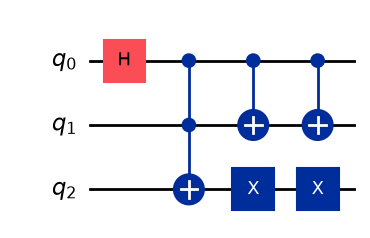

In [3]:
qc.draw(output='mpl')

In [4]:
print("Gate count:", qc.size())
print("Depth:", qc.depth())
print("Operations:", qc.count_ops())

Gate count: 6
Depth: 4
Operations: OrderedDict([('cx', 2), ('x', 2), ('h', 1), ('ccx', 1)])


In [5]:
from qiskit.converters import circuit_to_dag

dag = circuit_to_dag(qc)

print("Number of operation nodes:")
print(dag.op_nodes())

Number of operation nodes:
[DAGOpNode(op=Instruction(name='h', num_qubits=1, num_clbits=0, params=[]), qargs=(<Qubit register=(3, "q"), index=0>,), cargs=()), DAGOpNode(op=Instruction(name='ccx', num_qubits=3, num_clbits=0, params=[]), qargs=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>), cargs=()), DAGOpNode(op=Instruction(name='cx', num_qubits=2, num_clbits=0, params=[]), qargs=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>), cargs=()), DAGOpNode(op=Instruction(name='cx', num_qubits=2, num_clbits=0, params=[]), qargs=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>), cargs=()), DAGOpNode(op=Instruction(name='x', num_qubits=1, num_clbits=0, params=[]), qargs=(<Qubit register=(3, "q"), index=2>,), cargs=()), DAGOpNode(op=Instruction(name='x', num_qubits=1, num_clbits=0, params=[]), qargs=(<Qubit register=(3, "q"), index=2>,), cargs=())]


In [6]:
pip install graphviz

Note: you may need to restart the kernel to use updated packages.


In [8]:
%pip install pydot graphviz


  Using cached pydot-4.0.1-py3-none-any.whl.metadata (11 kB)
Using cached pydot-4.0.1-py3-none-any.whl (37 kB)
Note: you may need to restart the kernel to use updated packages.


In [ ]:
for node in dag.op_nodes():

    predecessors = dag.predecessors(node)
    successors = dag.successors(node)

    print("\nGate:", node.name)

    print(
        "Predecessors:",
        [n.name for n in predecessors if hasattr(n, "name")]
    )

    print(
        "Successors:",
        [n.name for n in successors if hasattr(n, "name")]
    )


Gate: h
Predecessors: []
Successors: ['ccx']

Gate: ccx
Predecessors: ['h']
Successors: ['x', 'cx']

Gate: cx
Predecessors: ['ccx']
Successors: ['cx']

Gate: cx
Predecessors: ['cx']
Successors: []

Gate: x
Predecessors: ['ccx']
Successors: ['x']

Gate: x
Predecessors: ['x']
Successors: []


In [ ]:
decomposed = qc.decompose()

print(decomposed)

     ┌────────────┐                                             ┌───┐ »
q_0: ┤ U(π/2,0,π) ├──────────────■─────────────────────■────■───┤ T ├─»
     └────────────┘              │             ┌───┐   │  ┌─┴─┐┌┴───┴┐»
q_1: ────────────────■───────────┼─────────■───┤ T ├───┼──┤ X ├┤ Tdg ├»
         ┌───┐     ┌─┴─┐┌─────┐┌─┴─┐┌───┐┌─┴─┐┌┴───┴┐┌─┴─┐├───┤└┬───┬┘»
q_2: ────┤ H ├─────┤ X ├┤ Tdg ├┤ X ├┤ T ├┤ X ├┤ Tdg ├┤ X ├┤ T ├─┤ H ├─»
         └───┘     └───┘└─────┘└───┘└───┘└───┘└─────┘└───┘└───┘ └───┘ »
«                                  
«q_0: ─────■───────────■────────■──
«        ┌─┴─┐       ┌─┴─┐    ┌─┴─┐
«q_1: ───┤ X ├───────┤ X ├────┤ X ├
«     ┌──┴───┴───┐┌──┴───┴───┐└───┘
«q_2: ┤ U(π,0,π) ├┤ U(π,0,π) ├─────
«     └──────────┘└──────────┘     


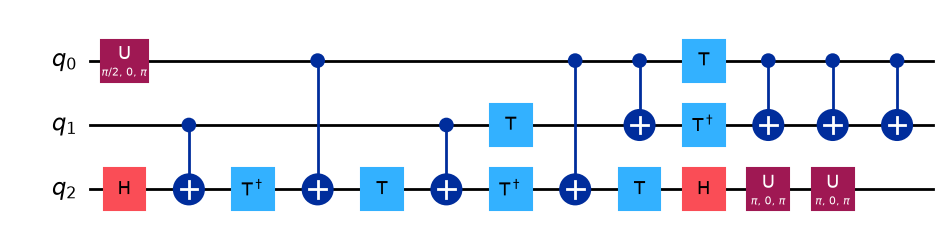

In [ ]:
qc.decompose().draw(output='mpl')

In [ ]:
print("Original:")
print(qc.count_ops())

print("\nAfter decomposition:")
print(decomposed.count_ops())

print("\nOriginal depth:", qc.depth())
print("Decomposed depth:", decomposed.depth())

Original:
OrderedDict([('cx', 2), ('x', 2), ('h', 1), ('ccx', 1)])

After decomposition:
OrderedDict([('cx', 8), ('t', 4), ('u', 3), ('tdg', 3), ('h', 2)])

Original depth: 4
Decomposed depth: 13
